<a href="https://colab.research.google.com/github/marinhotechdev-ia/InteligenciaArtificial/blob/main/deteccao_anomalias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de Anomalias em Logs de Acesso - Isolation Forest
Análise não supervisionada para identificação de perfis de acesso atípicos.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import os

# 1. Carga e Exploração de Dados
df = pd.read_csv('acessos_sistema.csv')
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nStats:")
print(df.describe())

Shape: (80, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   hora_acesso                   80 non-null     int64
 1   duracao_sessao_min            80 non-null     int64
 2   numero_tentativas_login       80 non-null     int64
 3   ip_diferente_habitual         80 non-null     int64
 4   quantidade_paginas_acessadas  80 non-null     int64
dtypes: int64(5)
memory usage: 3.3 KB
None

Stats:
       hora_acesso  duracao_sessao_min  numero_tentativas_login  \
count    80.000000           80.000000                80.000000   
mean     10.350000           58.037500                 3.187500   
std       7.549164           76.105929                 3.284385   
min       0.000000            1.000000                 1.000000   
25%       2.000000            4.000000                 1.000000   
50%      11.000000      

In [7]:
# 2. Pré-processamento e Escalonamento
scaler = StandardScaler()
features = ['hora_acesso', 'duracao_sessao_min', 'numero_tentativas_login', 'ip_diferente_habitual', 'quantidade_paginas_acessadas']
X_scaled = scaler.fit_transform(df[features])

In [8]:
model = IsolationForest(contamination=0.08, random_state=42)
model.fit(X_scaled)
df['anomaly_score'] = model.decision_function(X_scaled)
df['is_anomaly'] = model.predict(X_scaled) # 1 = normal, -1 = anomalia
df['is_anomaly'] = df['is_anomaly'].map({1: 0, -1: 1}) # 0 = normal, 1 = anomalia

print(df['is_anomaly'].value_counts())

is_anomaly
0    73
1     7
Name: count, dtype: int64


--- Perfil Médio: Normal vs Anômalo ---
is_anomaly                            0           1
hora_acesso                   10.287671   11.000000
duracao_sessao_min            45.849315  185.142857
numero_tentativas_login        3.287671    2.142857
ip_diferente_habitual          0.452055    1.000000
quantidade_paginas_acessadas  17.890411   76.857143


/tmp/ipykernel_3085/1095073609.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_anomaly', y='numero_tentativas_login', palette='coolwarm')


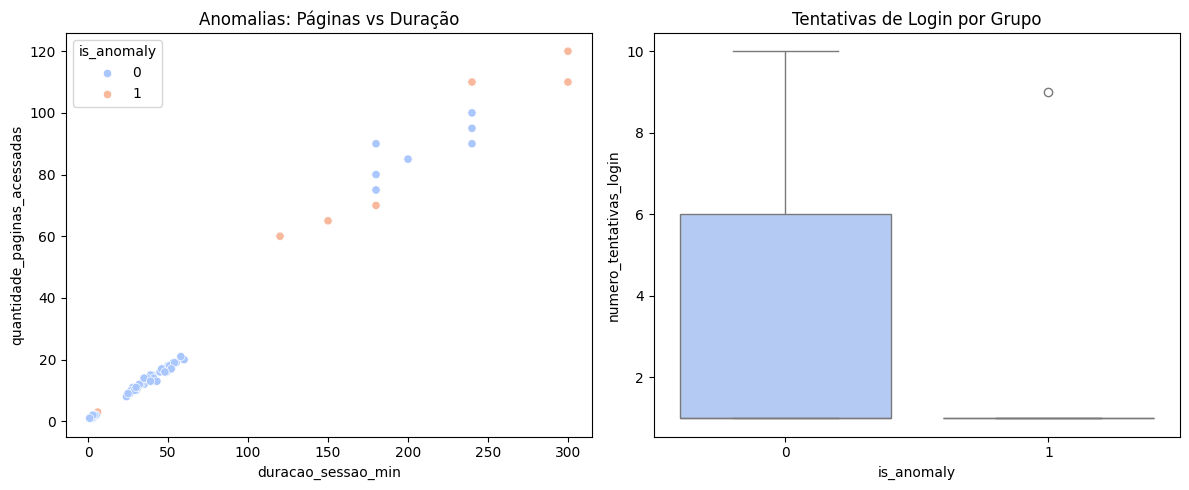

In [9]:
# 4. Análise de Características dos Perfis e Visualização
print("--- Perfil Médio: Normal vs Anômalo ---")
print(df.groupby('is_anomaly')[features].mean().T)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='duracao_sessao_min', y='quantidade_paginas_acessadas', hue='is_anomaly', palette='coolwarm')
plt.title('Anomalias: Páginas vs Duração')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='is_anomaly', y='numero_tentativas_login', palette='coolwarm')
plt.title('Tentativas de Login por Grupo')
plt.tight_layout()
plt.show()

# 5. Relatório Técnico e Respostas Teóricas
- **Padrões Normais:** Acessos em horário comercial, baixa latência/duração, poucas tentativas de login (1-2) e IP habitual.
- **Características Anômalas:** Alta concentração de acessos fora do horário comercial (madrugada), picos de tentativas de login (força bruta), IP alterado (`ip_diferente_habitual`=1) e comportamento discrepante de navegação.
- **Segurança vs Atipicidade:** Nem toda anomalia é ameaça. Mudanças de fuso horário de diretores ou tarefas automatizadas legítimas (backups cron) geram falsos positivos.
- **Falsos Positivos Comuns:** Usuário esquecendo a senha (múltiplas tentativas legítimas), auditorias agendadas de TI, ou acessos via VPN corporativa nova.
- **Implantação Real:** Deploy via pipeline de streaming (Kafka/Spark), inferência online do modelo salvando scores em Redis, disparando alertas em SIEM (Splunk/Elasticsearch) quando `anomaly_score` ultrapassar o threshold crítico.